In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
import sys
import pandas as pd
from os.path import join
from easydict import EasyDict as edict
import json
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append("/n/home12/binxuwang/Github/DiffusionAttnConsistency")
from scripts.parity_memorization_eval_cli import evaluate_experiment_memorization, compute_membership_counts

exp_names = sorted(os.listdir("/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"))
exp_names = [exp_name for exp_name in exp_names if "DiT" in exp_name]

/n/home12/binxuwang/Github/circuit_toolkit/circuit_toolkit/GAN_invert_utils.py:2: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange, tqdm


In [3]:
saveroot = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
mem_eval_syn_df = pd.read_csv(join(saveroot, "mem_eval_synopsis.csv"))

In [7]:
mem_eval_syn_df["step_per_sample"] = mem_eval_syn_df["step"] * 256 / mem_eval_syn_df["train_sample_num"]

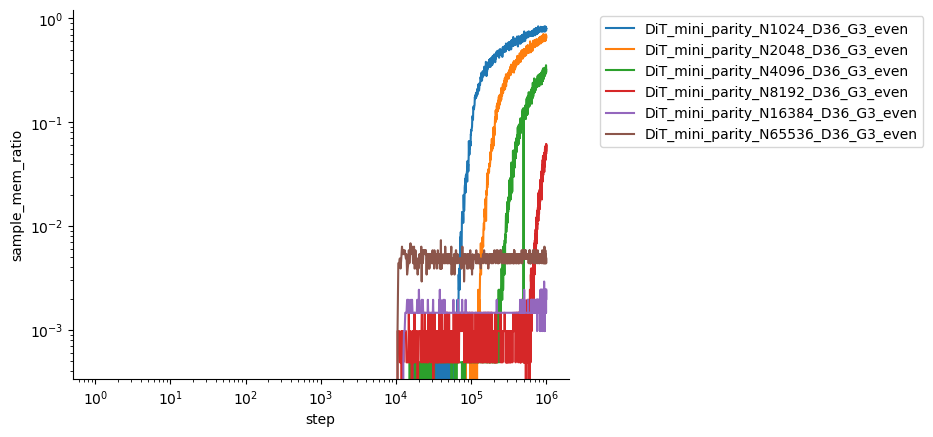

In [6]:
sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 3").sort_values(by="train_sample_num"))
plt.yscale("log")
plt.xscale("log")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

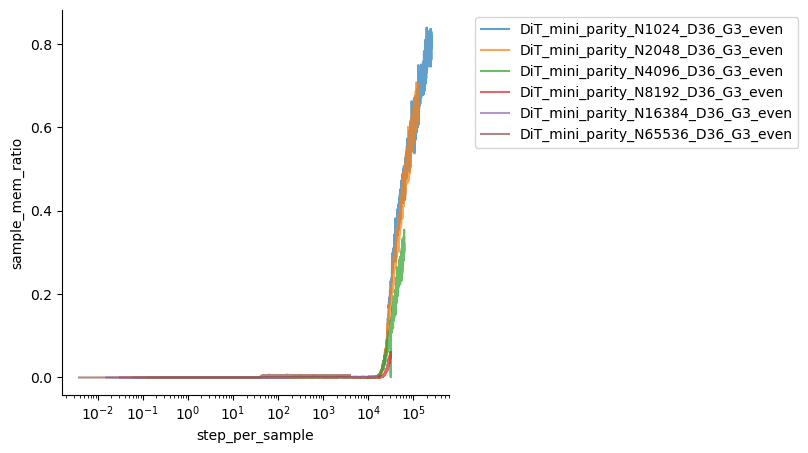

In [15]:
plt.figure(figsize=(5, 5))
sns.lineplot(x="step_per_sample", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 3").sort_values(by="train_sample_num"),
             alpha=0.7)
# plt.yscale("log")
plt.xscale("log")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

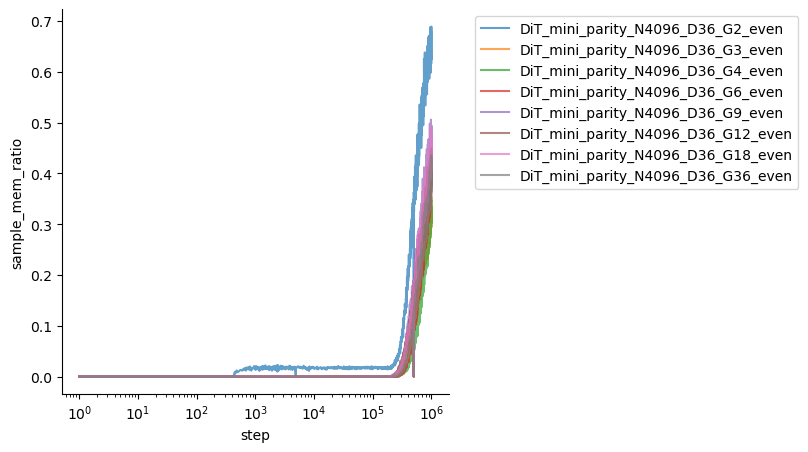

In [17]:
plt.figure(figsize=(5, 5))
sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and train_sample_num == 4096").sort_values(by="group_size"),
             alpha=0.7)
# plt.yscale("log")
plt.xscale("log")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [18]:
mem_eval_syn_df.columns

Index(['step', 'sample_mem_num', 'sample_mem_ratio', 'bitgroup_mem_num',
       'bitgroup_mem_ratio', 'sample_num', 'group_size', 'nan_num_eps_1e-1',
       'nan_ratio_eps_1e-1', 'nan_num_eps_1e-2', 'nan_ratio_eps_1e-2',
       'pergroup_parity_num', 'pergroup_parity_acc', 'sample_corr_num',
       'sample_corr_acc', 'exp_name', 'train_sample_num', 'num_groups',
       'DiT_nlayer', 'DiT_nhead', 'step_per_sample'],
      dtype='object')

### Learning speed as a function of Group size 

In [36]:
from circuit_toolkit.plot_utils import saveallforms
figdir = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/learning_curve_scaling"

In [37]:
def pergroup_parity_acc_baseline(G, D=36):
    return (1/2)

def sample_corr_baseline(G, D=36):
    return (1/2)**(D//G)

def bitgroup_mem_ratio_groundtruth_baseline(G, N=4096, D=36):
    return min(1.0, N * (D//G) / (2 ** (G-1)))

def bitgroup_mem_ratio_rand_baseline(G, N=4096, D=36):
    return min(N * (D//G), 2 ** (G-1)) / 2 ** G

def sample_mem_ratio_groundtruth_baseline(G, N=4096, D=36):
    return N / (2 ** (G-1)) ** (D // G)

def sample_mem_ratio_rand_baseline(G, N=4096, D=36):
    return N / 2 ** D

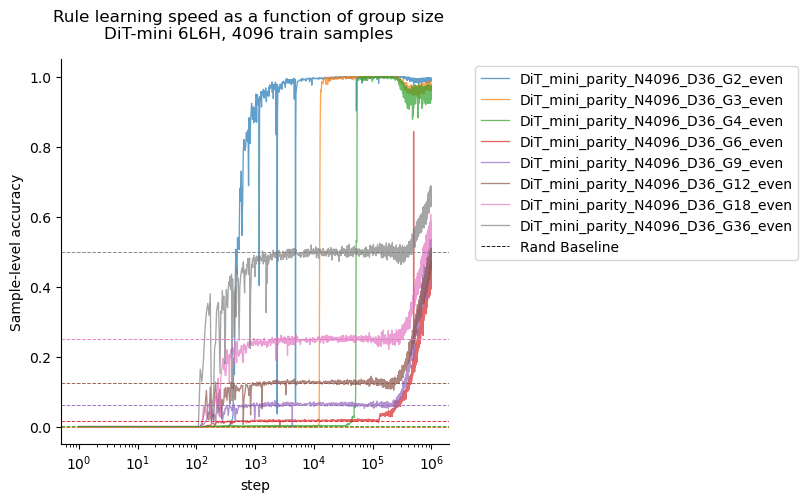

In [41]:
plt.figure(figsize=(5, 5))
sns.lineplot(x="step", y="sample_corr_acc", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and train_sample_num == 4096").sort_values(by="group_size"),
             alpha=0.7, lw=0.95)
for i, G in enumerate([2, 3, 4, 6, 9, 12, 18, 36]):
    plt.axhline(sample_corr_baseline(G), color=f"C{i}", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Rand Baseline')
# plt.yscale("log")
plt.xscale("log")
plt.ylim(-0.05, 1.05)
plt.ylabel("Sample-level accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle(f"Rule learning speed as a function of group size\nDiT-mini 6L6H, 4096 train samples")
saveallforms(figdir, "DiT_sample_corr_acc_G_scaling_N4096", plt.gcf())
plt.show()

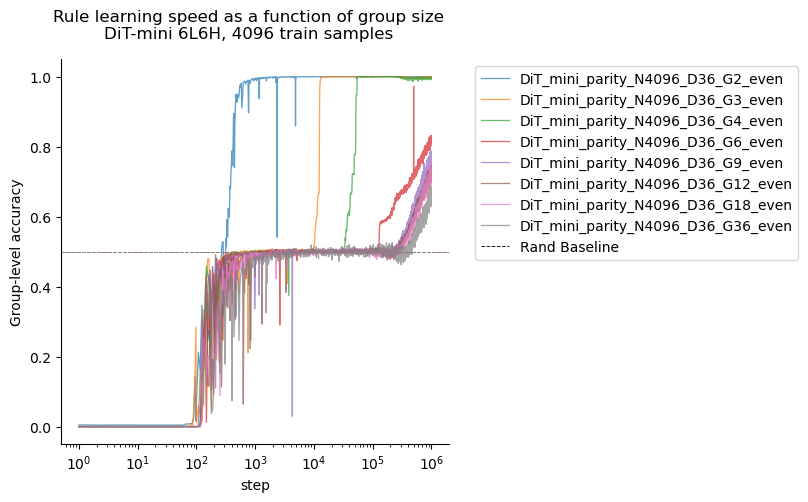

In [42]:
plt.figure(figsize=(5, 5))
sns.lineplot(x="step", y="pergroup_parity_acc", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and train_sample_num == 4096").sort_values(by="group_size"),
             alpha=0.7, lw=0.95)
for i, G in enumerate([2, 3, 4, 6, 9, 12, 18, 36]):
    plt.axhline(pergroup_parity_acc_baseline(G), color=f"C{i}", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Rand Baseline')
# plt.yscale("log")
plt.xscale("log")
plt.ylim(-0.05, 1.05)
plt.ylabel("Group-level accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle(f"Rule learning speed as a function of group size\nDiT-mini 6L6H, 4096 train samples")
saveallforms(figdir, "DiT_pergroup_parity_acc_G_scaling_N4096", plt.gcf())
plt.show()

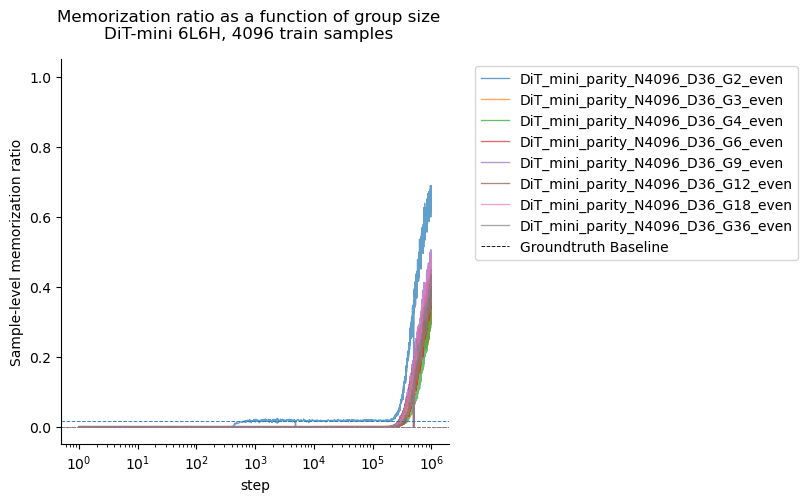

In [43]:
plt.figure(figsize=(5, 5))
sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and train_sample_num == 4096").sort_values(by="group_size"),
             alpha=0.7, lw=0.95)
for i, G in enumerate([2, 3, 4, 6, 9, 12, 18, 36]):
    plt.axhline(sample_mem_ratio_groundtruth_baseline(G), color=f"C{i}", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Groundtruth Baseline')
# plt.yscale("log")
plt.xscale("log")
plt.ylim(-0.05, 1.05)
plt.ylabel("Sample-level memorization ratio")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle(f"Memorization ratio as a function of group size\nDiT-mini 6L6H, 4096 train samples")
saveallforms(figdir, "DiT_sample_mem_ratio_G_scaling_N4096", plt.gcf())
plt.show()

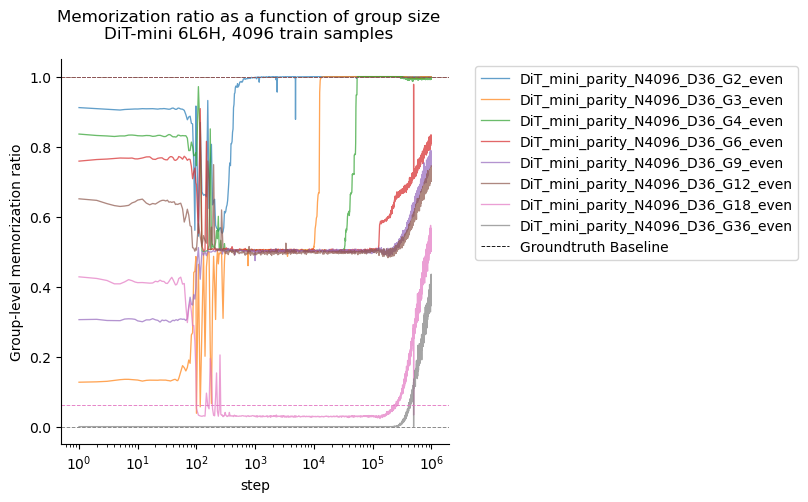

In [44]:
plt.figure(figsize=(5, 5))
sns.lineplot(x="step", y="bitgroup_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and train_sample_num == 4096").sort_values(by="group_size"),
             alpha=0.7, lw=0.95)
# plt.yscale("log")
for i, G in enumerate([2, 3, 4, 6, 9, 12, 18, 36]):
    plt.axhline(bitgroup_mem_ratio_groundtruth_baseline(G), color=f"C{i}", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Groundtruth Baseline')
plt.xscale("log")
plt.ylim(-0.05, 1.05)
plt.ylabel("Group-level memorization ratio")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle(f"Memorization ratio as a function of group size\nDiT-mini 6L6H, 4096 train samples")
saveallforms(figdir, "DiT_bitgroup_mem_ratio_G_scaling_N4096", plt.gcf())
plt.show()

### Learning speed as a function of dataset size

In [ ]:
plt.figure(figsize=(5, 5))
sns.lineplot(x="step_per_sample", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == 3").sort_values(by="train_sample_num"),
             alpha=0.7, lw=0.95)
# plt.yscale("log")
plt.xscale("log")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

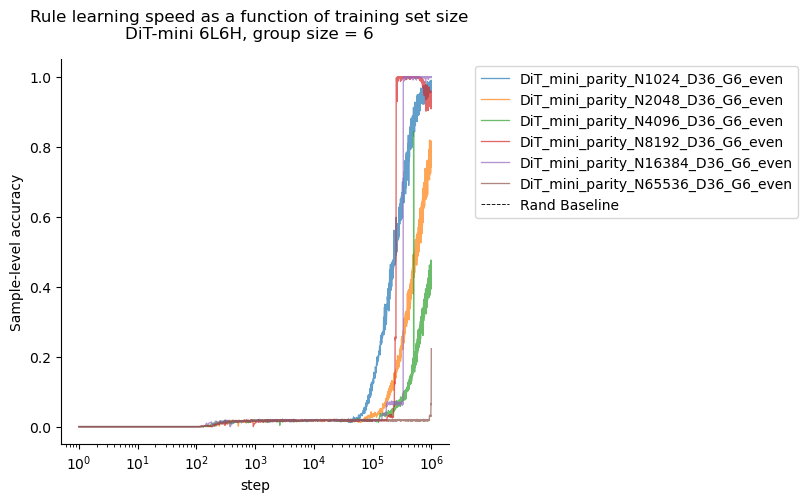

In [53]:
plt.figure(figsize=(5, 5))
group_size = 6
sns.lineplot(x="step", y="sample_corr_acc", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == @group_size").sort_values(by="train_sample_num"),
             alpha=0.7, lw=0.95)
# for i, G in enumerate([2, 3, 4, 6, 9, 12, 18, 36]):
#     plt.axhline(sample_corr_baseline(G), color=f"C{i}", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Rand Baseline')
# plt.yscale("log")
plt.xscale("log")
plt.ylim(-0.05, 1.05)
plt.ylabel("Sample-level accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle(f"Rule learning speed as a function of training set size\nDiT-mini 6L6H, group size = {group_size}")
# saveallforms(figdir, "DiT_sample_corr_acc_G_scaling_N4096", plt.gcf())
plt.show()

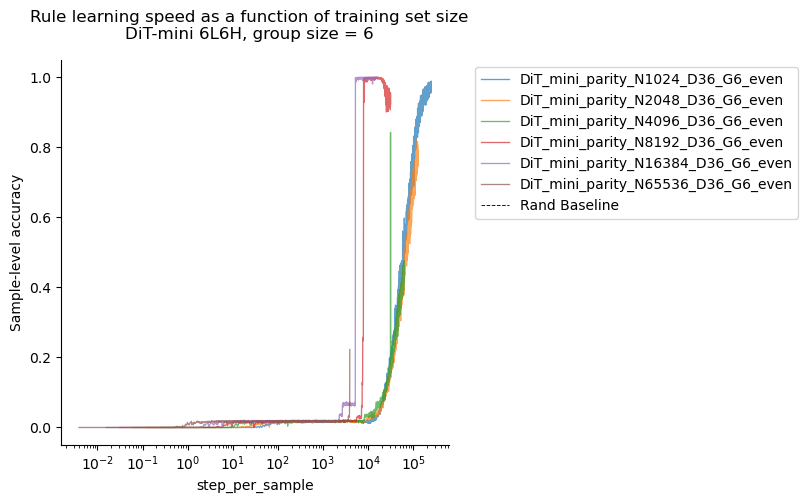

In [61]:
plt.figure(figsize=(5, 5))
group_size = 6
sns.lineplot(x="step_per_sample", y="sample_corr_acc", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == @group_size").sort_values(by="train_sample_num"),
             alpha=0.7, lw=0.95)
# for i, G in enumerate([2, 3, 4, 6, 9, 12, 18, 36]):
#     plt.axhline(sample_corr_baseline(G), color=f"C{i}", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Rand Baseline')
# plt.yscale("log")
plt.xscale("log")
plt.ylim(-0.05, 1.05)
plt.ylabel("Sample-level accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle(f"Rule learning speed as a function of training set size\nDiT-mini 6L6H, group size = {group_size}")
# saveallforms(figdir, "DiT_sample_corr_acc_G_scaling_N4096", plt.gcf())
plt.show()

### Systematic dataset scaling 

In [71]:
figdir

'/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/learning_curve_scaling'

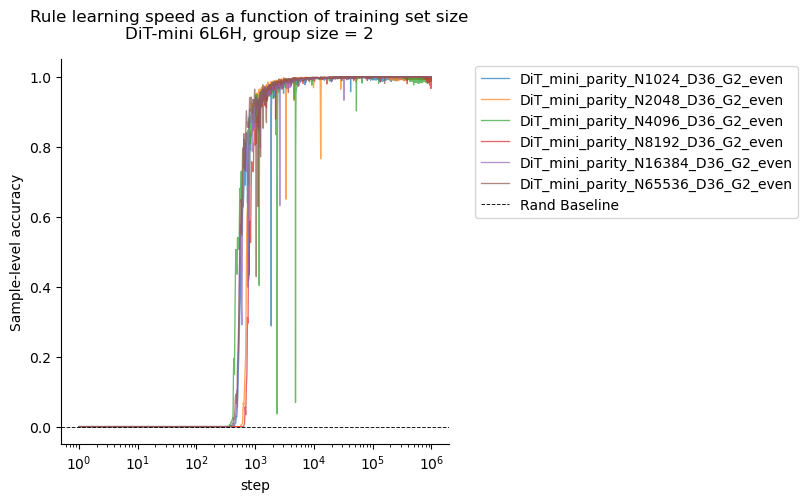

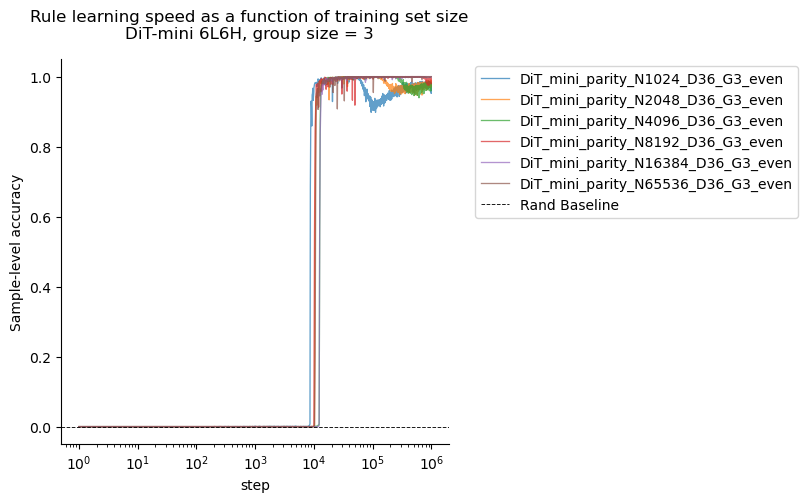

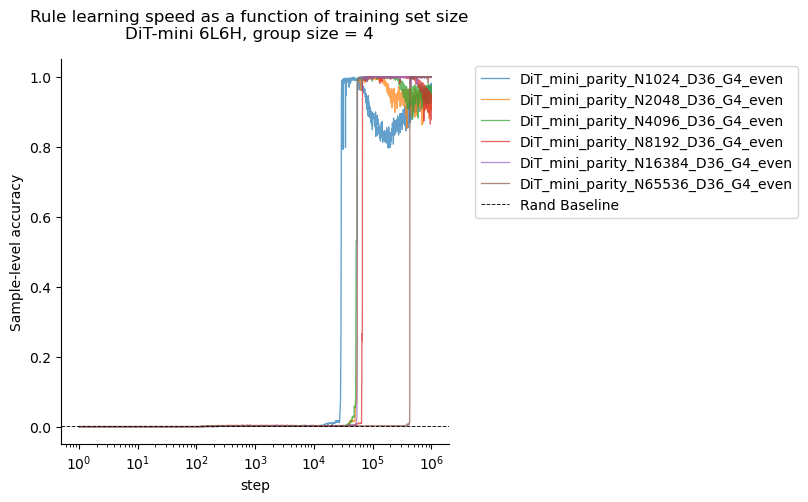

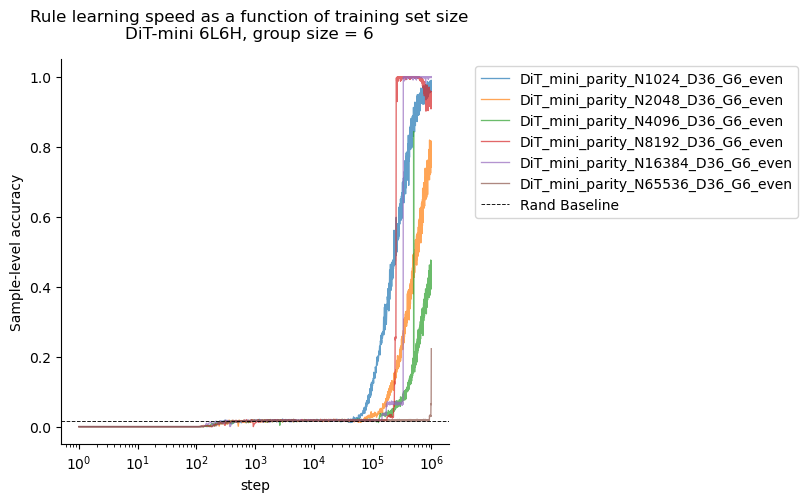

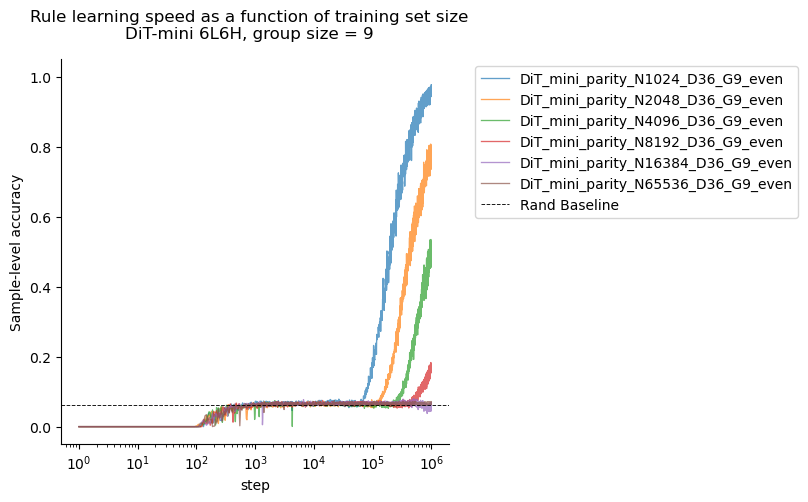

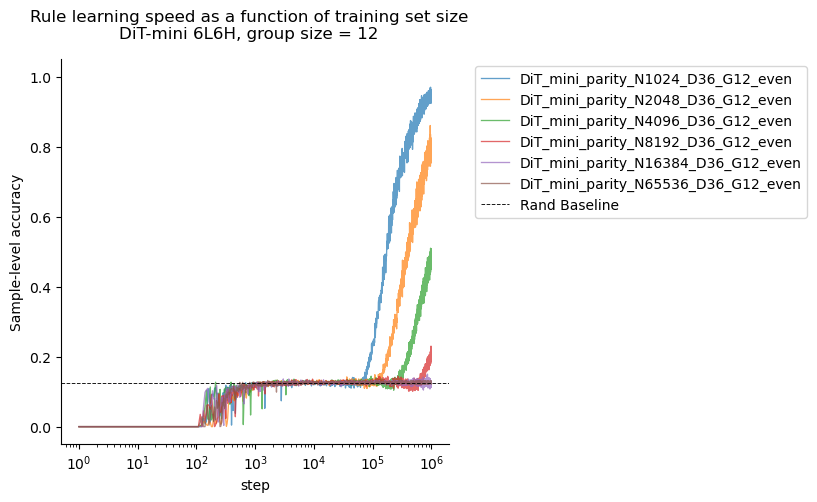

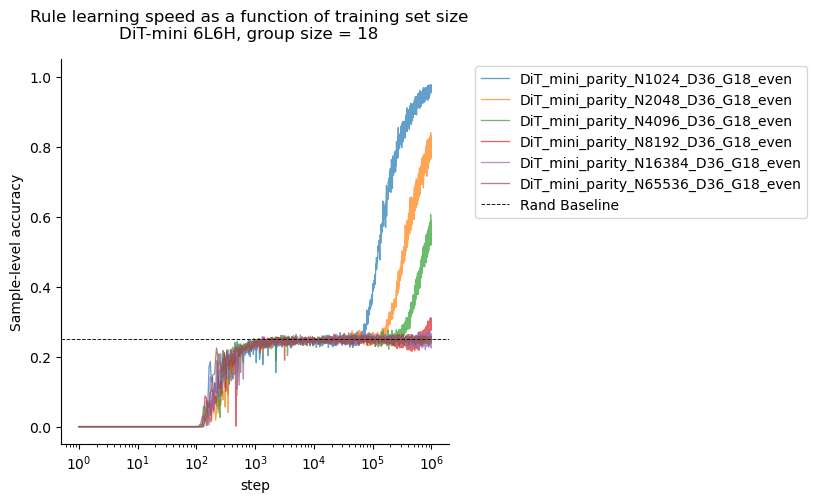

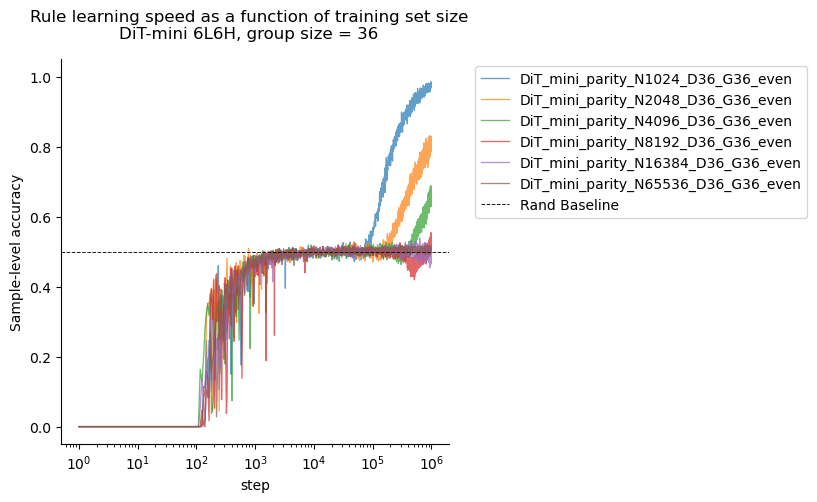

In [74]:
group_size = 2
for group_size in [2, 3, 4, 6, 9, 12, 18, 36]:
    plt.figure(figsize=(5, 5))
    dataset_sizes = sorted(mem_eval_syn_df["train_sample_num"].unique())
    sns.lineplot(x="step", y="sample_corr_acc", hue="exp_name", 
                data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == @group_size").sort_values(by="train_sample_num"),
                alpha=0.7, lw=0.95)
    # for i, dataset_size in enumerate(dataset_sizes):
    plt.axhline(sample_corr_baseline(G=group_size), color=f"k", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
    plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Rand Baseline')
    # plt.yscale("log")
    plt.xscale("log")
    plt.ylim(-0.05, 1.05)
    plt.ylabel("Sample-level accuracy")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f"Rule learning speed as a function of training set size\nDiT-mini 6L6H, group size = {group_size}")
    saveallforms(figdir, f"DiT_sample_corr_acc_dataset_N_scaling_G{group_size}_DiT-mini", plt.gcf())
    plt.show()

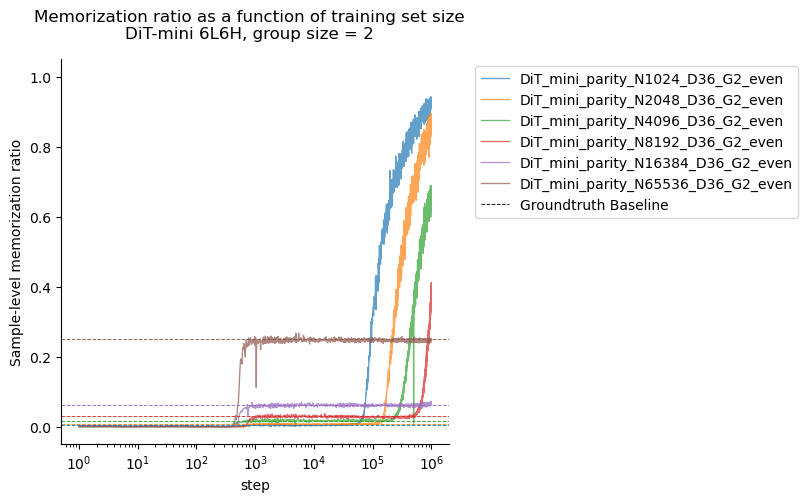

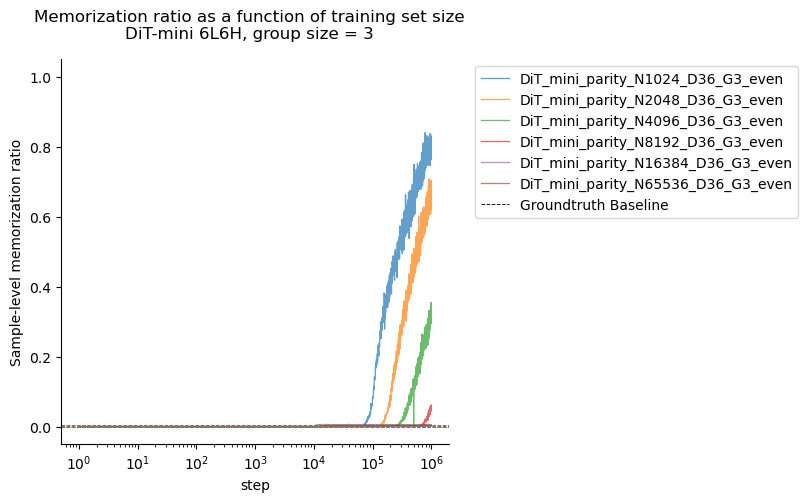

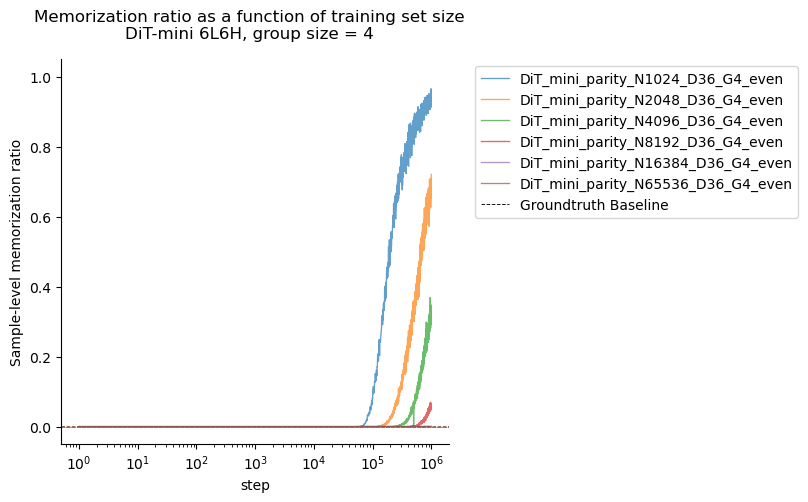

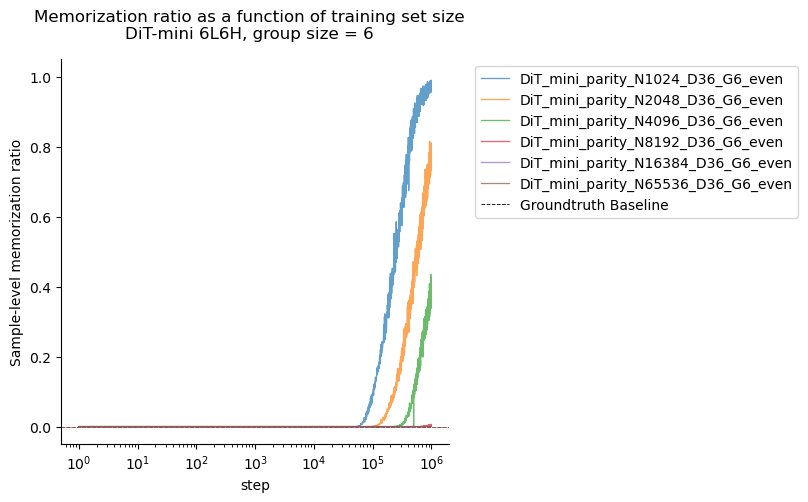

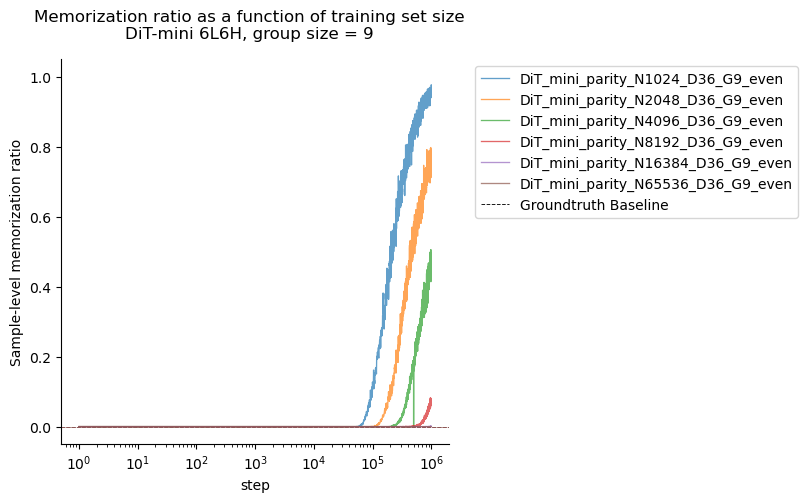

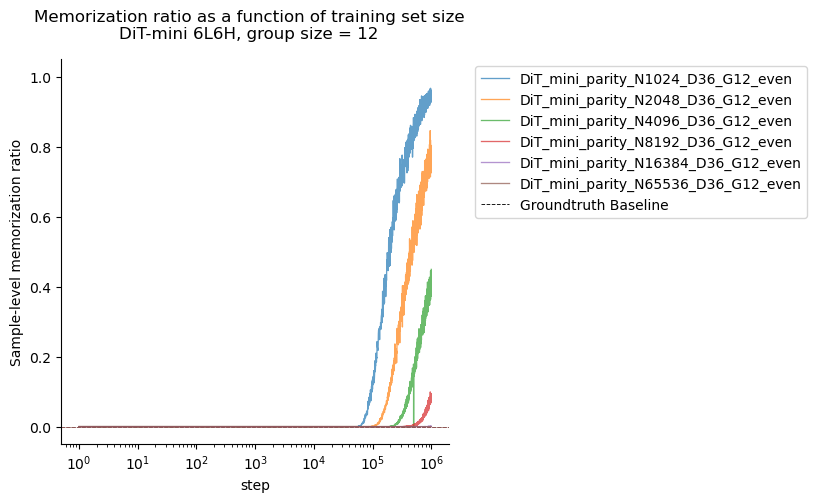

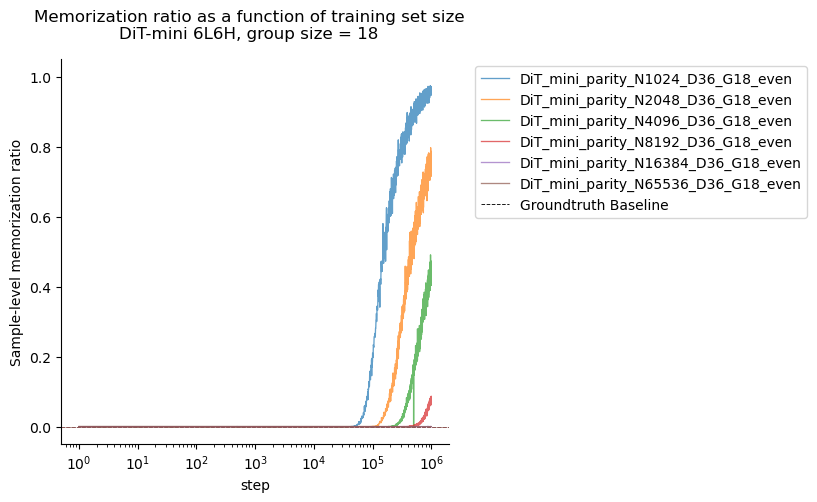

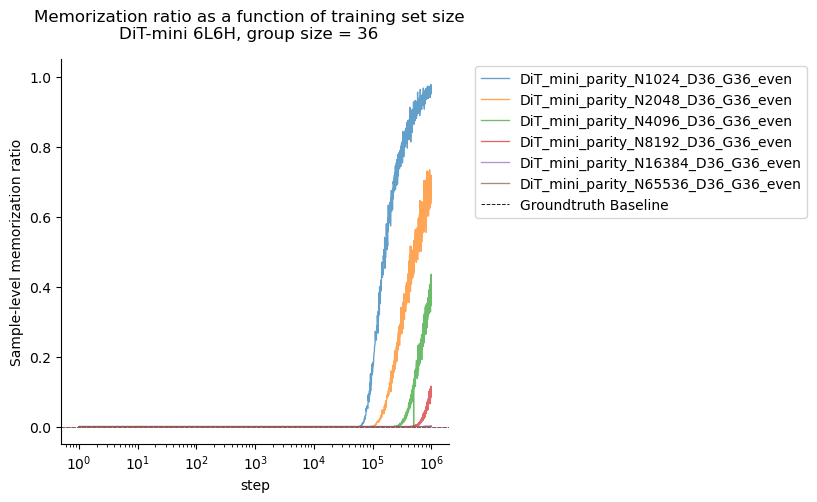

In [72]:
group_size = 2
for group_size in [2, 3, 4, 6, 9, 12, 18, 36]:
    plt.figure(figsize=(5, 5))
    dataset_sizes = sorted(mem_eval_syn_df["train_sample_num"].unique())
    sns.lineplot(x="step", y="sample_mem_ratio", hue="exp_name", 
                data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == @group_size").sort_values(by="train_sample_num"),
                alpha=0.7, lw=0.95)
    for i, dataset_size in enumerate(dataset_sizes):
        plt.axhline(sample_mem_ratio_groundtruth_baseline(G=group_size, N=dataset_size), color=f"C{i}", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
    plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Groundtruth Baseline')
    # plt.yscale("log")
    plt.xscale("log")
    plt.ylim(-0.05, 1.05)
    plt.ylabel("Sample-level memorization ratio")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f"Memorization ratio as a function of training set size\nDiT-mini 6L6H, group size = {group_size}")
    saveallforms(figdir, f"DiT_sample_mem_ratio_dataset_N_scaling_G{group_size}_DiT-mini", plt.gcf())
    plt.show()

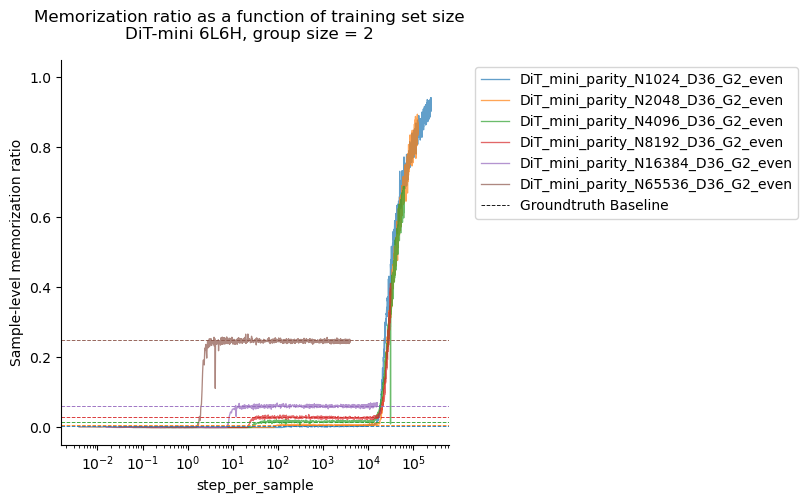

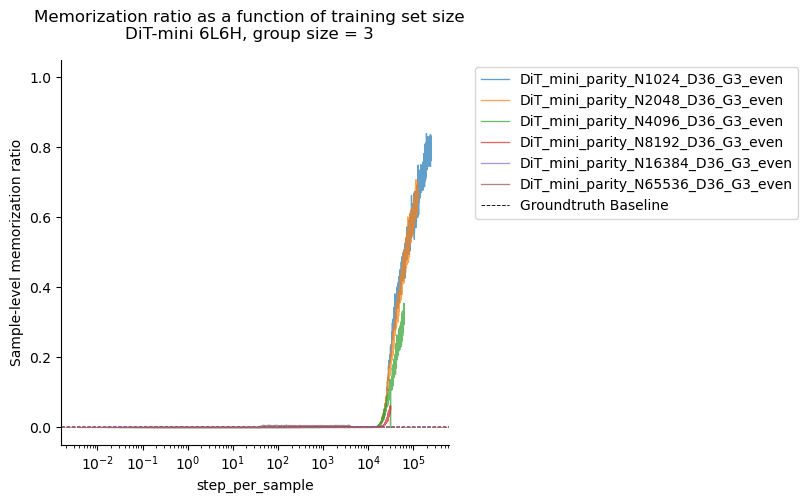

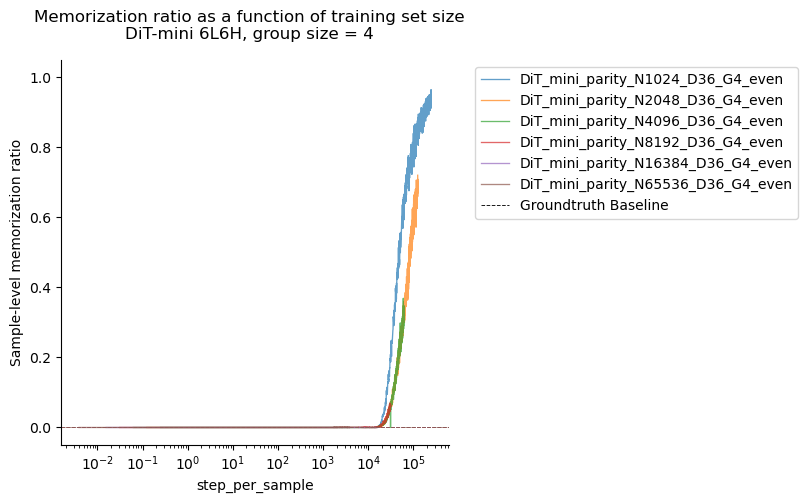

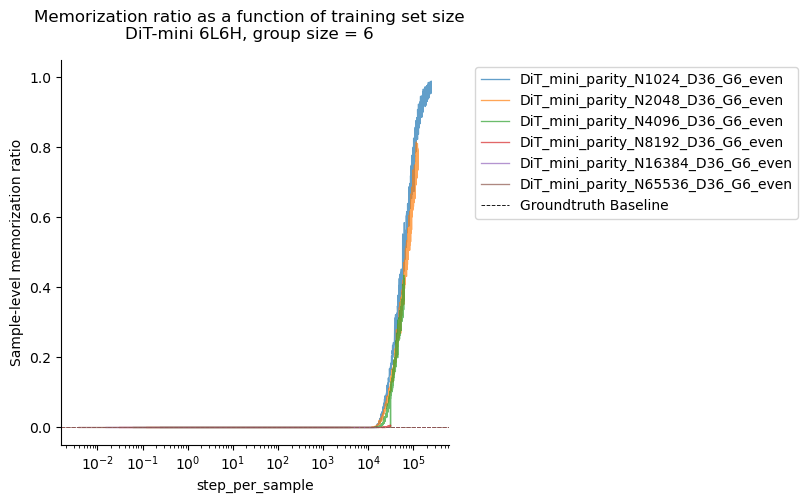

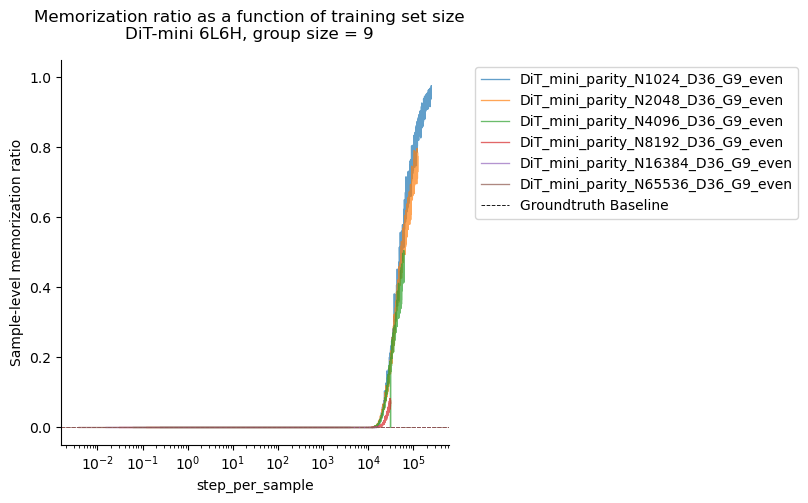

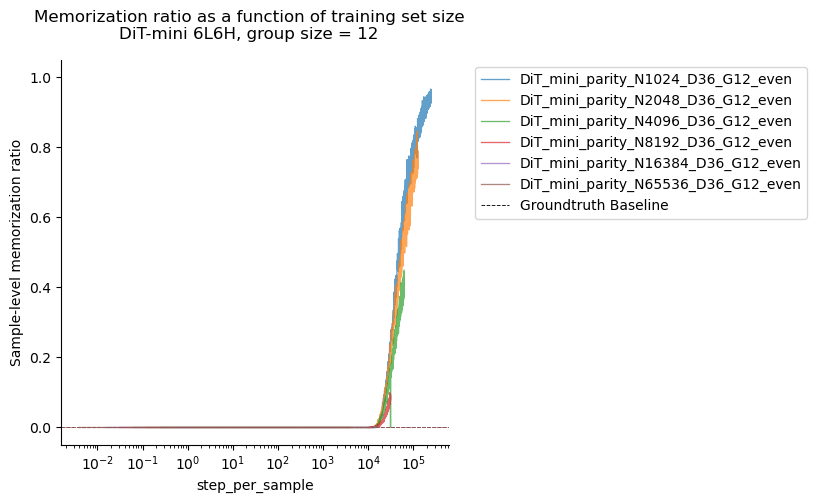

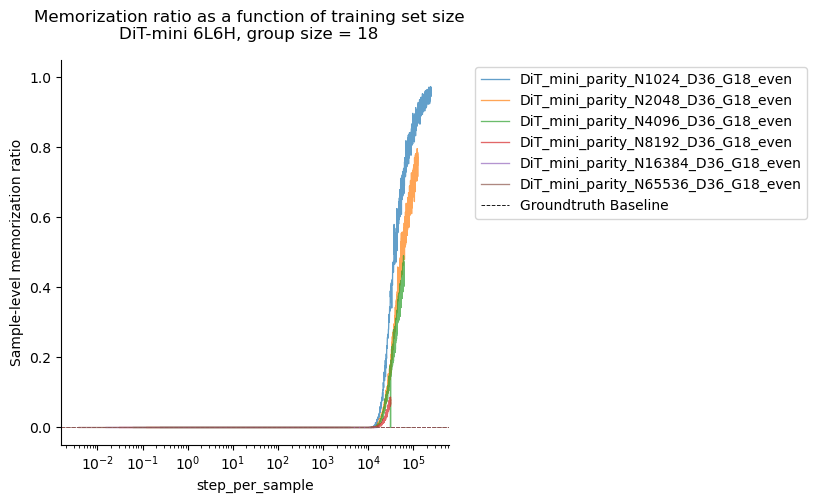

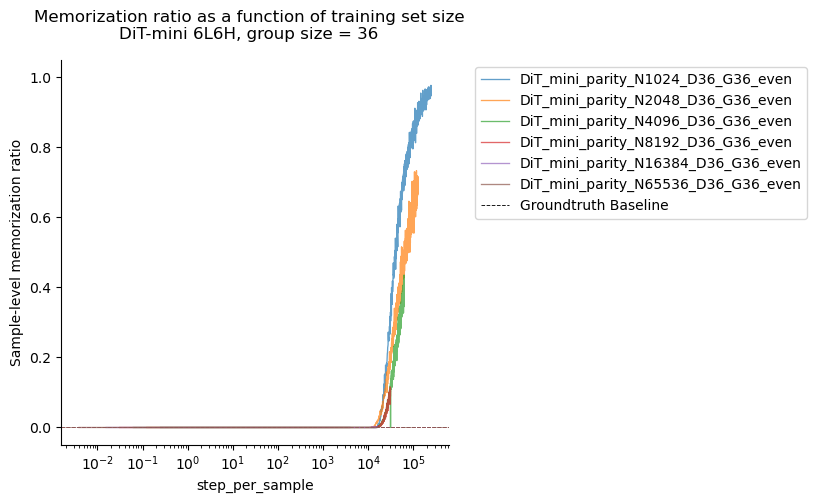

In [73]:
for group_size in [2, 3, 4, 6, 9, 12, 18, 36]:
    plt.figure(figsize=(5, 5))
    dataset_sizes = sorted(mem_eval_syn_df["train_sample_num"].unique())
    sns.lineplot(x="step_per_sample", y="sample_mem_ratio", hue="exp_name", 
                data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == @group_size").sort_values(by="train_sample_num"),
                alpha=0.7, lw=0.95)
    for i, dataset_size in enumerate(dataset_sizes):
        plt.axhline(sample_mem_ratio_groundtruth_baseline(G=group_size, N=dataset_size), color=f"C{i}", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
    plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Groundtruth Baseline')
    # plt.yscale("log")
    plt.xscale("log")
    plt.ylim(-0.05, 1.05)
    plt.ylabel("Sample-level memorization ratio")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.suptitle(f"Memorization ratio as a function of training set size\nDiT-mini 6L6H, group size = {group_size}")
    saveallforms(figdir, f"DiT_sample_mem_ratio_dataset_N_scaling_G{group_size}_DiT-mini_step_per_sample", plt.gcf())
    plt.show()

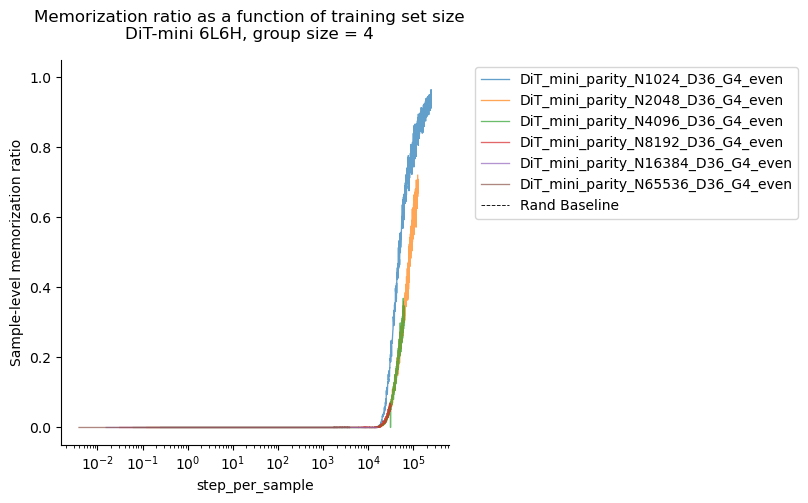

In [62]:
plt.figure(figsize=(5, 5))
group_size = 4
sns.lineplot(x="step_per_sample", y="sample_mem_ratio", hue="exp_name", 
             data=mem_eval_syn_df.query("DiT_nlayer == 6 and group_size == @group_size").sort_values(by="train_sample_num"),
             alpha=0.7, lw=0.95)
# for i, G in enumerate([2, 3, 4, 6, 9, 12, 18, 36]):
#     plt.axhline(sample_corr_baseline(G), color=f"C{i}", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Rand Baseline')
# plt.yscale("log")
plt.xscale("log")
plt.ylim(-0.05, 1.05)
plt.ylabel("Sample-level memorization ratio")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle(f"Memorization ratio as a function of training set size\nDiT-mini 6L6H, group size = {group_size}")
# saveallforms(figdir, "DiT_sample_corr_acc_G_scaling_N4096", plt.gcf())
plt.show()

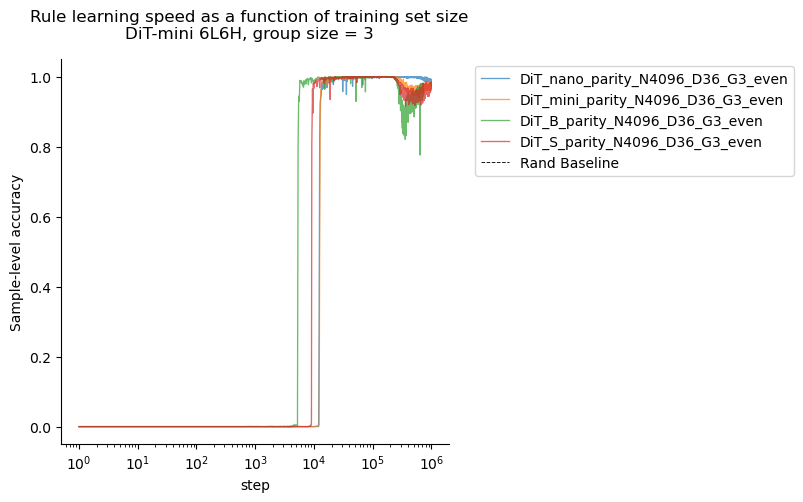

In [65]:
plt.figure(figsize=(5, 5))
group_size = 3
sns.lineplot(x="step", y="sample_corr_acc", hue="exp_name", 
             data=mem_eval_syn_df.query("train_sample_num == 4096 and group_size == @group_size").sort_values(by="DiT_nlayer"),
             alpha=0.7, lw=0.95)
# for i, G in enumerate([2, 3, 4, 6, 9, 12, 18, 36]):
#     plt.axhline(sample_corr_baseline(G), color=f"C{i}", linestyle='--', linewidth=0.7, alpha=0.9, )#label='Rand Baseline')
plt.plot([], [], color='k', linestyle='--', linewidth=0.7, alpha=0.9, label='Rand Baseline')
# plt.yscale("log")
plt.xscale("log")
plt.ylim(-0.05, 1.05)
plt.ylabel("Sample-level accuracy")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle(f"Rule learning speed as a function of training set size\nDiT-mini 6L6H, group size = {group_size}")
# saveallforms(figdir, "DiT_sample_corr_acc_G_scaling_N4096", plt.gcf())
plt.show()

In [ ]:
mem_eval_syn_df.columns

Index(['step', 'sample_mem_num', 'sample_mem_ratio', 'bitgroup_mem_num',
       'bitgroup_mem_ratio', 'sample_num', 'group_size', 'nan_num_eps_1e-1',
       'nan_ratio_eps_1e-1', 'nan_num_eps_1e-2', 'nan_ratio_eps_1e-2',
       'pergroup_parity_num', 'pergroup_parity_acc', 'sample_corr_num',
       'sample_corr_acc', 'exp_name', 'train_sample_num', 'num_groups',
       'DiT_nlayer', 'DiT_nhead', 'step_per_sample'],
      dtype='object')